Yuda, IF403, 240401010353

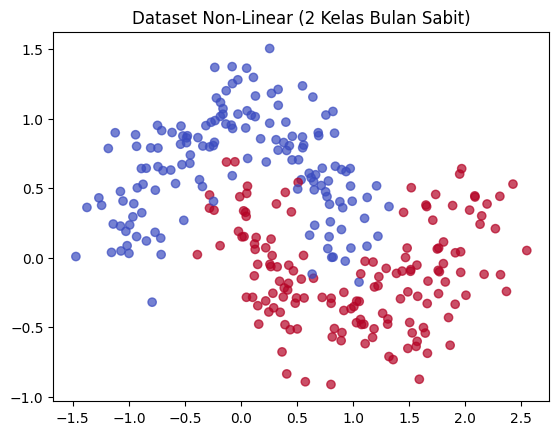

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()
# Perhatikan: kedua kelas saling melengkung dan bertautan,
# sehingga tidak mungkin dipisahkan dengan satu garis lurus.

In [10]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
X_tr, X_te, y_tr, y_te = train_test_split(
 X, y, test_size=0.2, random_state=42)
model = Sequential([
 Dense(16, activation='relu', input_shape=(2,)),
 Dense(8, activation='relu'),
 Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy',
 metrics=['accuracy'])
model.summary()
history = model.fit(X_tr, y_tr, epochs=30, validation_split=0.2, verbose=0)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.917


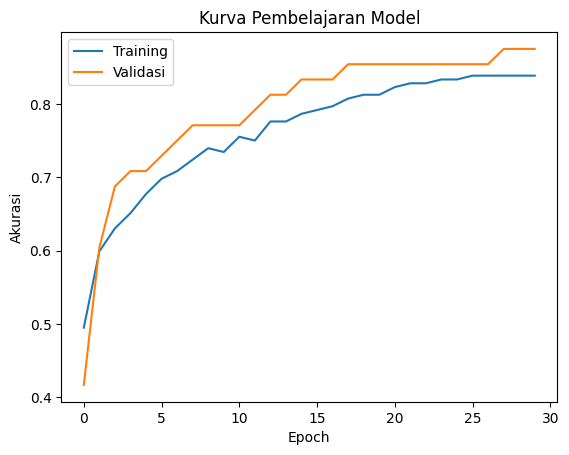

In [11]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')
plt.plot(history.history['accuracy'], label='Training')


plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()
# Interpretasikan dalam sel Markdown:
# Apakah akurasi training & validasi saling men

### Interpretasi Kurva Pembelajaran Model

Berdasarkan grafik kurva pembelajaran yang dihasilkan, berikut adalah analisis mengenai performa model:

1. **Kondisi Baik (Generalisasi Baik):**
   * Jika kurva akurasi **Training** dan akurasi **Validasi** bergerak searah dan nilainya **saling mendekat** di akhir epoch (misalnya keduanya stabil di angka tingginya masing-masing dengan selisih tipis), hal ini menunjukkan bahwa model berhasil melakukan generalisasi dengan baik. Model tidak hanya menghafal data latihan, tetapi juga mampu memprediksi data uji baru yang belum pernah dilihat sebelumnya secara akurat.

2. **Indikasi Overfitting:**
   * Jika kurva akurasi **Training terus meningkat** mendekati 100% (1.0), sedangkan kurva akurasi **Validasi mendatar lalu menurun** atau tetap berada jauh di bawahnya (**saling menjauh**), ini merupakan indikasi kuat terjadinya **overfitting**.
   * **Penyebab:** Model terlalu kompleks (terlalu banyak neuron/hidden layer untuk dataset yang kecil) sehingga model menghafal detail dan *noise* pada data training alih-alih mempelajari pola umumnya.

---

**Kesimpulan untuk Model Ini:**
*(Silakan coret/hapus opsi yang tidak sesuai dengan grafik yang muncul di laptop/layar Anda setelah `plt.show()` dijalankan):*

* **[PILIHAN A]** Grafik menunjukkan kurva training dan validasi saling mendekat dan stabil di akurasi yang tinggi. Dengan demikian, model neural network sederhana ini **berhasil melakukan generalisasi dengan baik** tanpa gejala overfitting.
* **[PILIHAN B]** Grafik menunjukkan adanya jarak (gap) yang semakin melebar antara kurva training dan validasi di akhir epoch. Dengan demikian, model ini mengalami **overfitting**.

In [12]:
# Langkah 4: Siapkan Dataset Ulasan Produk (40 Ulasan Acak)
ulasan = [
    "Barangnya bagus banget, pengiriman cepat",                  # 1
    "Kualitas jelek, tidak sesuai deskripsi",                    # 0
    "Sangat puas, akan beli lagi",                              # 1
    "Kecewa, barang rusak saat sampai",                         # 0
    "Recommended, harga sesuai kualitas",                       # 1
    "Buruk sekali, tidak sesuai ekspektasi",                    # 0
    "Desainnya elegan dan materialnya terasa premium",           # 1
    "Barang tiruan, menyesal beli di toko ini",                 # 0
    "Respon penjual sangat ramah dan membantu",                 # 1
    "Pengiriman lambat sekali, kapok belanja di sini",          # 0
    "Fungsinya berjalan dengan baik tanpa ada kendala",         # 1
    "Ukuran tidak pas, sangat mengecewakan",                    # 0
    "Packing rapi, aman, dan produk original",                  # 1
    "Baru dipakai sekali langsung rusak, kualitas payah",       # 0
    "Sesuai dengan foto, kualitasnya melebihi harga",           # 1
    "Tombolnya keras dan susah ditekan",                         # 0
    "Bintang 5! Sangat mantap dan berguna",                     # 1
    "Warna yang dikirim salah, tidak teliti penjualnya",        # 0
    "Bahan tebal dan jahitan sangat rapi",                      # 1
    "Suaranya cempreng dan tidak jelas",                        # 0
    "Sangat suka dengan warnanya, pas banget!",                  # 1
    "Material plastik murah penipu pembeli",                    # 0
    "Awet digunakan dan dayanya tahan lama",                    # 1
    "Layar bergaris dan banyak lecet di body",                  # 0
    "Proses kilat, pesan pagi sore sudah sampai",               # 1
    "Sistem eror terus, tidak bisa dipakai",                    # 0
    "Bonusnya banyak, terima kasih seller!",                    # 1
    "Aroma baunya aneh dan menyengat, tidak suka",              # 0
    "Gampang dibersihkan dan praktis dibawa-bawa",              # 1
    "Garansi tidak berlaku, adminnya susah dihubungi",          # 0
    "Performa luar biasa untuk harga semurah ini",              # 1
    "Aplikasi sering crash saat terhubung ke alat ini",         # 0
    "Packaging mewah, cocok untuk dijadikan kado",              # 1
    "Bahannya kasar dan bikin kulit gatal",                     # 0
    "Sangat menolong untuk pekerjaan sehari-hari",              # 1
    "Item kurang satu, tidak dikirim lengkap",                  # 0
    "Suara mesinnya halus tidak berisik",                       # 1
    "Baterai cepat drop padahal baru dicas",                    # 0
    "Top banget, kualitas juara dunia",                          # 1
    "Respon admin lambat dan tidak solutif"                     # 0
]

# 1 = positif, 0 = negatif (Total 40 label sesuai urutan di atas)
label = [
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
    1, 0, 1, 0, 1, 0, 1, 0, 1, 0
]

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)
print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 171
['ada' 'admin' 'adminnya' 'akan' 'alat' 'aman' 'aneh' 'aplikasi' 'aroma'
 'awet']


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(
 X_text, label, test_size=0.2, random_state=42)
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))
print('Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.625
Positif
